# **Fundamentos de Aprendizaje por Refuerzo**
## ***Regresión Lineal Simple***

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Cargar dataset

In [2]:
# Cargar el conjunto de datos
data = pd.read_csv(filepath_or_buffer='https://raw.githubusercontent.com/cdavid2804/test-1/main/datos_produccion.csv')
print(np.shape(data))
data.head(10)

(50, 4)


,Semana,Horas Trabajadas,Horas Descanso,Productos Terminados
0,1,42,2,28.9
1,2,45,3,30.6
2,3,30,2,21.1
3,4,33,2,21.8
4,5,33,3,19.3
5,6,37,3,26.3
6,7,39,2,28.1
7,8,49,2,28.4
8,9,48,2,29.4
9,10,34,2,21.1


## Observación datos

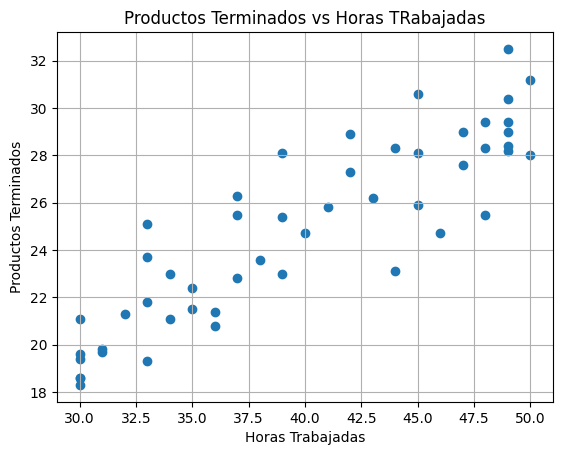

In [3]:
X = data['Horas Trabajadas']
y = data['Productos Terminados']

##vector
X = X.values
y = y.values

##grafica
plt.scatter(X,y)
plt.xlabel("Horas Trabajadas")
plt.ylabel("Productos Terminados")
plt.title("Productos Terminados vs Horas TRabajadas")
plt.grid()


## División de datos

In [24]:
n = X.shape[0]
train_ratio = 0.7 #70% datos de entrenamiento (30% datos de prueba)

train_size = int(n * train_ratio) #numero de muestras para training
test_size = n - train_size #numero de muestras para test

np.random.seed(0) #anula efecto random
indices = np.random.permutation(n) #crea array de indices de rango 0 hasta n (n = 50) con valores aleatorios


train_indices = indices[:train_size] #hacia izquierda
test_indices = indices[train_size:] #hacia derecha

X_train, y_train = X[train_indices], y[train_indices]# crea array en X e y con datos de entrenamiento
X_test, y_test = X[test_indices], y[test_indices]# crea array en X e y con datos de prueba

print(f"Training data: {np.shape(X_train)}")# imprime resultado de datos de entrenamiento
print(f"Test data: {np.shape(X_test)}")# imprime resultado de datos de prueba


Training data: (35,)
Test data: (15,)


## Modelo de regresión lineal simple
Considerando un modelo
$$\hat{y_i} = \beta_0 + \beta_1x_i $$
$$\varepsilon_i =  \hat{y_i} - y_i  $$

$\varepsilon_i$ es el error residaual en la i-ésima observación. Entonces el objetivo es minimizar el error residual total. Entonces se define el error al cuadrado o función de costo, $J$ como:

$$J(\beta_0,\beta_1)=\frac{1}{2n}\sum^{n}_{i=1}\varepsilon_i^2$$

La tarea es encontrar el valor de $\beta_0$ y $\beta_1$ para el cual $J(\beta_0 , \beta_1 )$ es mínimo!.

Utilizando criterios de minimización se tiene:

$$\beta_1 = \frac{SSxy}{SSxx}$$

$$\beta_0 = \bar{y} - \beta_1\bar{x}$$

Donde $SSxy$ es la suma de las desviaciones cruzadas de $y$ y $x$:

$$SSxy = \sum^{n}_{i=1}(x_i-\bar{x})(y_i-\bar{y})$$

Y $SSxx$ es la suma de las desviaciones al cuadrado de $x$:

$$SSxx =  \sum^{n}_{i=1}(x_i-\bar{x})^2$$

In [25]:
def coeficientes(X, y):
  mean_X = sum(X) / len(X) #sum(X) calcula suma de datos dividido en len(X) cantidad de datos
  mean_y = sum(y) / len(y)
  SSxy = 0
  SSxx = 0
  for i in range(len(X)):
    SSxy += (X[i] - mean_X) * (y[i] - mean_y)
    SSxx += (X[i] - mean_X)**2

  beta_1 = SSxy / SSxx
  beta_0 = mean_y - (beta_1 * mean_X)

  return beta_0, beta_1



### Calcular los coeficiientes $\beta_0$ y $\beta_1$ y realizar predicciones

In [ ]:
beta_0, beta_1 = coeficientes(X_train, y_train)
print(f"Beta 0: {beta_0}")
print(f"Beta 1: {beta_1}")

Beta 0: 5.267226027397264
Beta 1: 0.49538527397260274


In [17]:
y_preb = beta_0 + beta_1 * X_test
print(f"X: {X_test}")
print(f"y preb: {y_preb}")# resultado de prediccion de y
print(f"y real: {y_test}")


X: [31 30 49 39 46 37 50 38 34 39 32 33 42 30 41]
y preb: [20.62416952 20.12878425 29.54110445 24.58725171 28.05494863 23.59648116
 30.03648973 24.09186644 22.11032534 24.58725171 21.11955479 21.61494007
 26.07340753 20.12878425 25.57802226]
y real: [19.7 18.6 28.2 28.1 24.7 22.8 28.  23.6 21.1 23.  21.3 21.8 28.9 18.3
 25.8]


## Evaluación del modelo

$$MSE = \frac{1}{n}\sum_{i=1}^n(\hat{y}_i-y_i)^2 $$
$$R^2=1-\frac{RSS}{TSS}; RSS=\sum_{i=1}^n(\hat{y}_i-y_i)^2; TSS=\sum_{i=1}^n(y_i-\bar{y}_i)^2$$


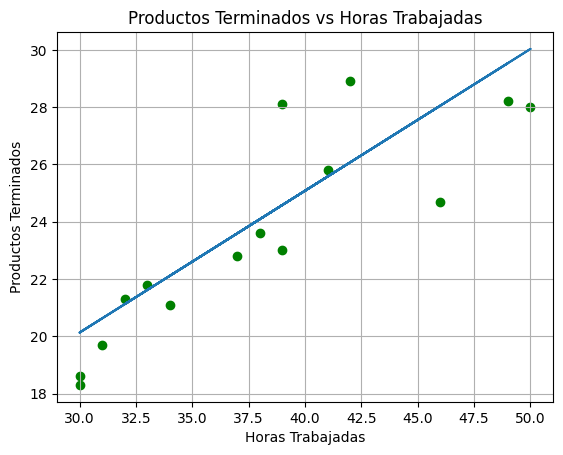

In [ ]:
plt.plot(X_test, y_preb) #linea recta
plt.scatter(X_test, y_test, c = "green") #puntos son datos de prueba
plt.xlabel("Horas Trabajadas")
plt.ylabel("Productos Terminados")
plt.title("Productos Terminados vs Horas Trabajadas")
plt.grid()

In [28]:
mse = np.mean((y_test - y_preb)**2)
rss = np.sum((y_test - y_preb)**2)
tts = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (rss/tts)
print(f"Mean Square Error (MSE): {mse}")
print(f"Coeficiente R2: {r2}")

Mean Square Error (MSE): 3.2399201109250915
Coeficiente R2: 0.7284821348914104


# **Descenso del Gradiente**

In [27]:
np.random.seed(42) #semilla que permite fijar valores
a = 3.5
b = 7.0
X = np.linspace(0, 10, 1000)
ruido = np.random.normal(0, 4, size = 1000)
y = a*X + b + ruido #crea ecuacion lineal



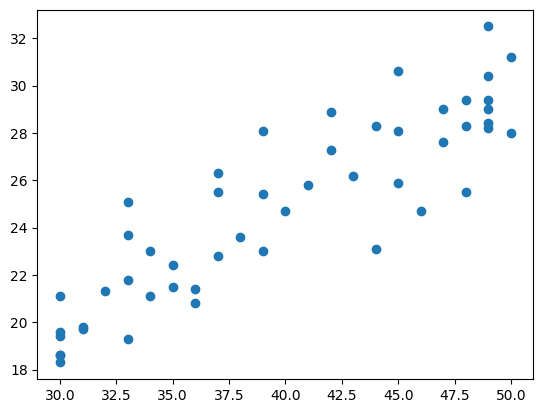

In [26]:
plt.scatter(X, y) #modela grafico

División de datos

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15) #test_size es un porcentaje para datos de prueba (se coloca como decimal)
print(f"Training data: {np.shape(X_train)}")# imprime resultado de datos de entrenamiento
print(f"Test data: {np.shape(X_test)}")# imprime resultado de datos de prueba


Training data: (850,)
Test data: (150,)


Calcular los coeficientes $\beta_0$ y $\beta_1$

In [30]:
np.random.seed(29) #genera el mismo valor
num_episodes = 2000
alpha = 0.0001 # taza de aprendizaje (learning rate)
loss = []
beta_0 = np.random.rand() #genera valor aleatorio entre 0 y 1
beta_1 = np.random.rand() #genera valor aleatorio entre 0 y 1

#ciclo que recorre desde 1 hasta 2000
for i in range(1,num_episodes+1):
  n = np.shape(X_train)[0] #Calcula dimension de conjunto de datos donde se actualiza beta0 y beta1
  y_preb = beta_0 + beta_1 * X_train #calcula salida predecida
  beta_0 = beta_0 - alpha*((2/n)*np.sum(y_preb - y_train)) # calcula ecuacion de los coeficientes beta_0
  beta_1 = beta_1 - alpha*((2/n)*np.sum((y_preb - y_train)*X_train))# calcula ecuacion de los coeficientes beta_1
  mse = (1/n)*(np.sum((y_preb - y_train)**2))# ecuacion para calcular la perdida con error cuantico
  loss.append(mse) # append almacena valores de mse
  print(f"Episode: {i}")
  print(f"Beta_0: {beta_0:.4f}, beta_1: {beta_1:.4f}")
  print(f"Loss: {mse:.4f}\n")


Episode: 1
Beta_0: 0.8682, beta_1: 0.3123
Loss: 592.7538

Episode: 2
Beta_0: 0.8726, beta_1: 0.3395
Loss: 585.0702

Episode: 3
Beta_0: 0.8770, beta_1: 0.3666
Loss: 577.4902

Episode: 4
Beta_0: 0.8813, beta_1: 0.3934
Loss: 570.0123

Episode: 5
Beta_0: 0.8856, beta_1: 0.4201
Loss: 562.6350

Episode: 6
Beta_0: 0.8899, beta_1: 0.4466
Loss: 555.3572

Episode: 7
Beta_0: 0.8942, beta_1: 0.4729
Loss: 548.1774

Episode: 8
Beta_0: 0.8985, beta_1: 0.4991
Loss: 541.0944

Episode: 9
Beta_0: 0.9027, beta_1: 0.5250
Loss: 534.1067

Episode: 10
Beta_0: 0.9069, beta_1: 0.5508
Loss: 527.2132

Episode: 11
Beta_0: 0.9110, beta_1: 0.5764
Loss: 520.4125

Episode: 12
Beta_0: 0.9151, beta_1: 0.6019
Loss: 513.7034

Episode: 13
Beta_0: 0.9193, beta_1: 0.6271
Loss: 507.0847

Episode: 14
Beta_0: 0.9233, beta_1: 0.6522
Loss: 500.5552

Episode: 15
Beta_0: 0.9274, beta_1: 0.6771
Loss: 494.1137

Episode: 16
Beta_0: 0.9314, beta_1: 0.7019
Loss: 487.7589

Episode: 17
Beta_0: 0.9354, beta_1: 0.7265
Loss: 481.4897

Episod

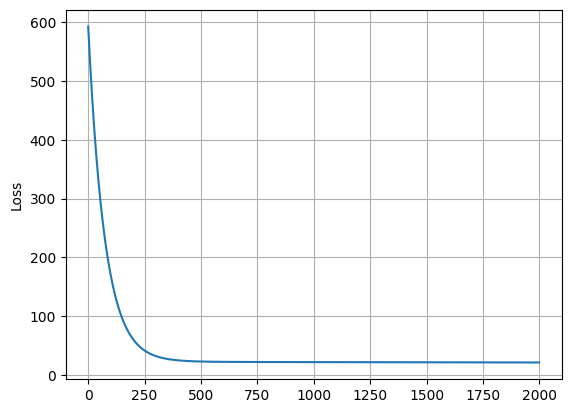

In [31]:
plt.plot(loss) #grafica perdidad de los valores de perdida de beta_0 y beta_1
# plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()

In [32]:
beta0, beta1 = coeficientes(X_train, y_train)

print(f"Beta0: {beta0}")
print(f"Beta1: {beta1}")

Beta0: 6.943295024828441
Beta1: 3.5170690057764733


COMPARACION


In [33]:
y_preb_1 = beta_0 + beta_1*X_train #usando el decenso del gradiente
y_preb_2 = beta0 + beta1*X_train #usando OLS

In [34]:
mse_1 = np.mean((y_train - y_preb_1)**2)
mse_2 = np.mean((y_train - y_preb_2)**2)

print(f"Mean Square Error (MSE) - GD: {mse_1}")
print(f"Mean Square Error (MSE) - OLS: {mse_2}")


Mean Square Error (MSE) - GD: 21.153379851758714
Mean Square Error (MSE) - OLS: 15.014943688125811
